In [101]:
from pymongo import MongoClient

#HOST="(...).mongodb.net"
HOST="cluster0.nl8aj.mongodb.net"
PORT=27017
USERNAME="madalinismana365"
PASSWORD="Madalin13245678..."

if HOST == 'localhost':
    if not USERNAME:
        cli_mongo = MongoClient(HOST, PORT)
    else:
        cli_mongo = MongoClient(HOST, PORT, USERNAME, PASSWORD)
else:
    cli_mongo = MongoClient(f"mongodb+srv://{USERNAME}:{PASSWORD}@{HOST}/test")

print (cli_mongo.list_database_names())
##usar la base de covid
db_covid=cli_mongo['covid']
#usar la coleccion de coviditalia
db_coviditalia=db_covid['coviditalia']

['Estudantes2', 'PruebaClase', 'RickyMorty', 'covid', 'sample_mflix', 'sample_restaurants', 'sample_supplies', 'admin', 'local']


In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [103]:
# Configuración
read_from_local = True
json_file = 'coviditalia.json'

if read_from_local:
    df = pd.read_json(json_file)
else:
    data = list(db_coviditalia.find())
    
    # Convertir ObjectId y otros tipos no serializables
    for doc in data:
        doc['_id'] = str(doc['_id'])  # Convertir ObjectId a string
    
    df = pd.DataFrame(data)
    
    # Limpieza de caracteres
    for col in df.select_dtypes(include=['object']):
        df[col] = df[col].apply(
            lambda x: x.encode('utf-8', 'ignore').decode('utf-8') 
            if isinstance(x, str) 
            else x
        )
    
    with open(json_file, 'w', encoding='utf-8') as f:
        json.dump(df.to_dict(orient='records'), f, ensure_ascii=False)

print(f"Datos cargados: {len(df)} registros")
print(df.head(10))

Datos cargados: 140180 registros
                        _id                 data stato  codice_regione  \
0  67dc7c48e0577331e8f40a50  2020-02-24T18:00:00   ITA              13   
1  67dc7c48e0577331e8f40a51  2020-02-24T18:00:00   ITA              13   
2  67dc7c48e0577331e8f40a52  2020-02-24T18:00:00   ITA              13   
3  67dc7c48e0577331e8f40a53  2020-02-24T18:00:00   ITA              13   
4  67dc7c48e0577331e8f40a54  2020-02-24T18:00:00   ITA              13   
5  67dc7c48e0577331e8f40a55  2020-02-24T18:00:00   ITA              17   
6  67dc7c48e0577331e8f40a56  2020-02-24T18:00:00   ITA              17   
7  67dc7c48e0577331e8f40a57  2020-02-24T18:00:00   ITA              17   
8  67dc7c48e0577331e8f40a58  2020-02-24T18:00:00   ITA              18   
9  67dc7c48e0577331e8f40a59  2020-02-24T18:00:00   ITA              18   

  denominazione_regione  codice_provincia  \
0               Abruzzo                66   
1               Abruzzo                67   
2               A

In [104]:
# Use the existing DataFrame `df` instead of redefining it
df = df.copy()

In [105]:
df = df.drop(columns=['codice_nuts_1', 'codice_nuts_2', 'codice_nuts_3', 'note'])

In [106]:
df.head(10)

,_id,data,stato,codice_regione,denominazione_regione,codice_provincia,denominazione_provincia,sigla_provincia,lat,long,totale_casi
0,67dc7c48e0577331e8f40a50,2020-02-24T18:00:00,ITA,13,Abruzzo,66,L'Aquila,AQ,42.351222,13.398438,1
1,67dc7c48e0577331e8f40a51,2020-02-24T18:00:00,ITA,13,Abruzzo,67,Teramo,TE,42.658918,13.704400,0
2,67dc7c48e0577331e8f40a52,2020-02-24T18:00:00,ITA,13,Abruzzo,68,Pescara,PE,42.464584,14.213648,0
3,67dc7c48e0577331e8f40a53,2020-02-24T18:00:00,ITA,13,Abruzzo,69,Chieti,CH,42.351032,14.167546,0
4,67dc7c48e0577331e8f40a54,2020-02-24T18:00:00,ITA,13,Abruzzo,979,In fase di definizione/aggiornamento,None,NaN,NaN,0
5,67dc7c48e0577331e8f40a55,2020-02-24T18:00:00,ITA,17,Basilicata,76,Potenza,PZ,40.639471,15.805148,0
6,67dc7c48e0577331e8f40a56,2020-02-24T18:00:00,ITA,17,Basilicata,77,Matera,MT,40.667512,16.597924,0
7,67dc7c48e0577331e8f40a57,2020-02-24T18:00:00,ITA,17,Basilicata,980,In fase di definizione/aggiornamento,None,NaN,NaN,0
8,67dc7c48e0577331e8f40a58,2020-02-24T18:00:00,ITA,18,Calabria,78,Cosenza,CS,39.293087,16.256097,0
9,67dc7c48e0577331e8f40a59,2020-02-24T18:00:00,ITA,18,Calabria,79,Catanzaro,CZ,38.905976,16.594402,0


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140180 entries, 0 to 140179
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   _id                      140180 non-null  object 
 1   data                     140180 non-null  object 
 2   stato                    140180 non-null  object 
 3   codice_regione           140180 non-null  int64  
 4   denominazione_regione    140180 non-null  object 
 5   codice_provincia         140180 non-null  int64  
 6   denominazione_provincia  140180 non-null  object 
 7   sigla_provincia          102506 non-null  object 
 8   lat                      102506 non-null  float64
 9   long                     102506 non-null  float64
 10  totale_casi              140180 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 11.8+ MB


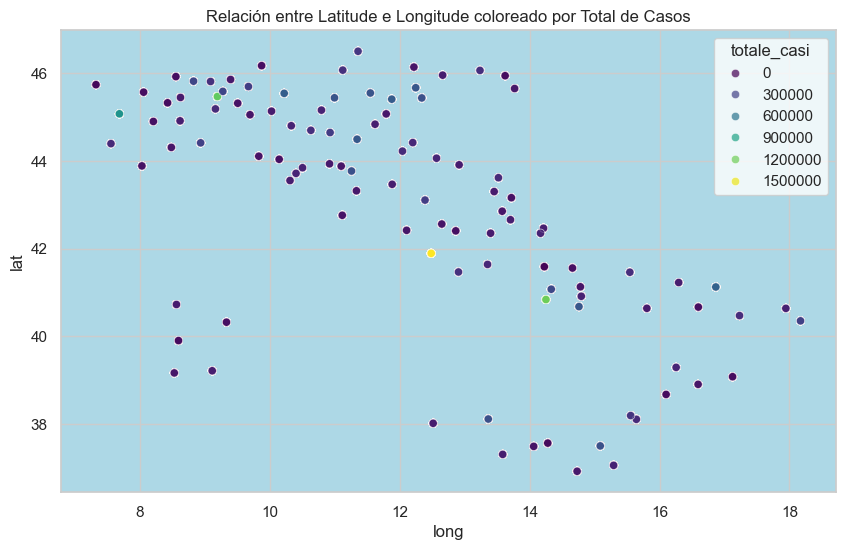

In [ ]:
# Gráfico 1: Scatterplot (relación entre latitude e longitude, coloreado por total de casos)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.scatterplot(data=df, x='long', y='lat', hue='totale_casi', palette='viridis', alpha=0.7)
plt.title('Relación entre Latitude e Longitude coloreado por Total de Casos')
plt.gca().set_facecolor('lightblue')
plt.show()

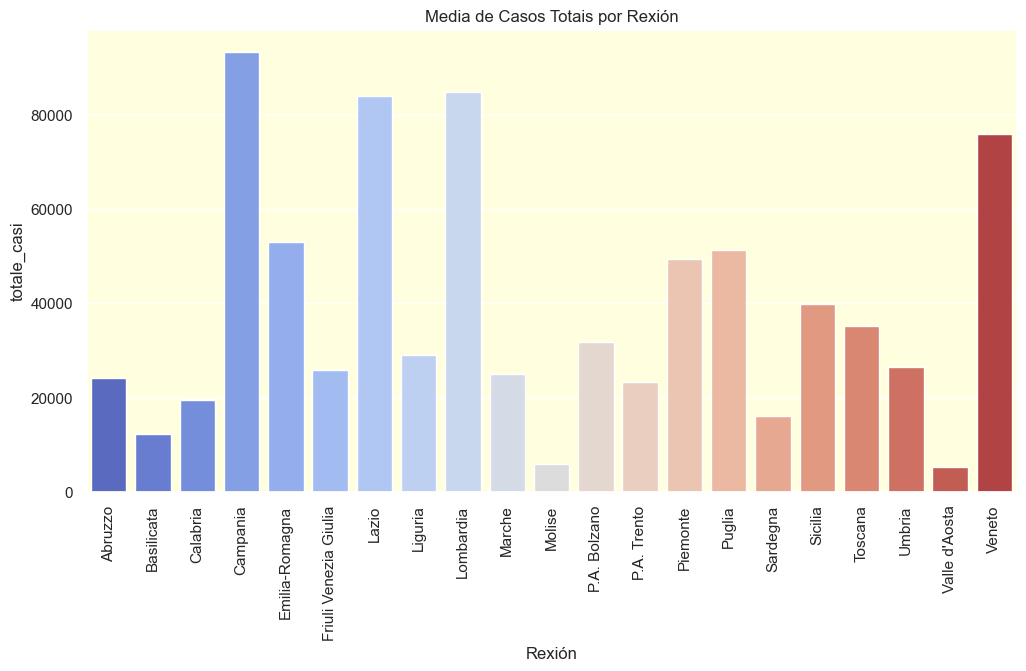

In [ ]:
# Gráfico 2: Barplot (media de casos totais por rexión)
plt.figure(figsize=(12, 6))
sns.set_theme(style="darkgrid")
sns.barplot(data=df, x='denominazione_regione', y='totale_casi', 
            errorbar=None, estimator=np.mean, hue='denominazione_regione', 
            palette='coolwarm', legend=False)
plt.xticks(rotation=90)
plt.gca().set_facecolor('lightyellow')
plt.xlabel('Rexión')
plt.title('Media de Casos Totais por Rexión')
plt.show()

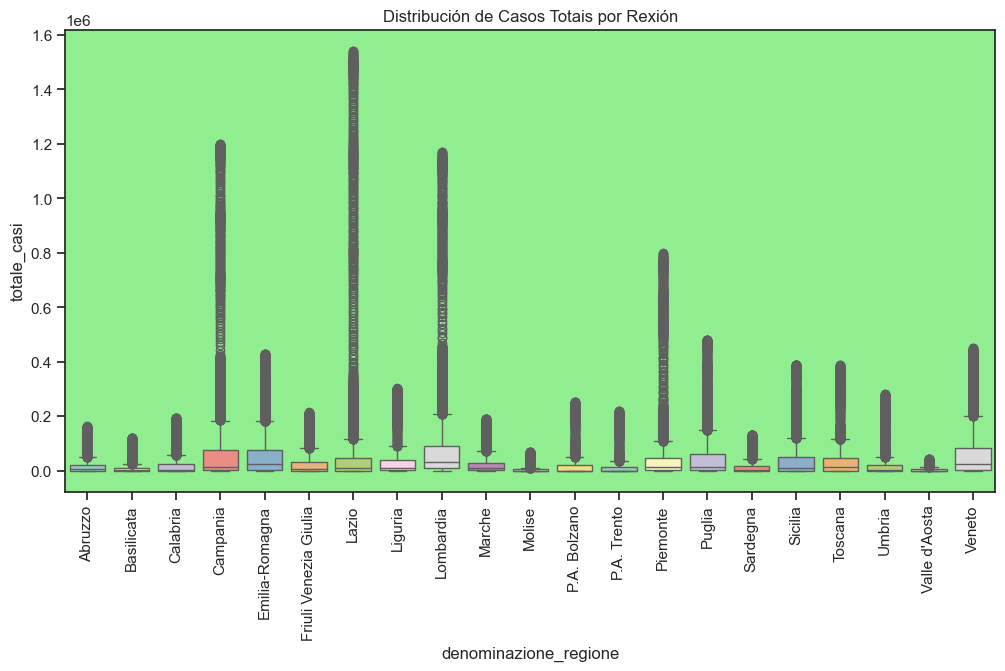

In [ ]:
# Gráfico 3: Boxplot (distribución de casos totais por rexión)
plt.figure(figsize=(12, 6))
sns.set_theme(style="ticks")
sns.boxplot(data=df, x='denominazione_regione', y='totale_casi', 
            hue='denominazione_regione', palette='Set3', legend=False)
plt.xticks(rotation=90)
plt.gca().set_facecolor('lightgreen')
plt.title('Distribución de Casos Totais por Rexión')
plt.show()

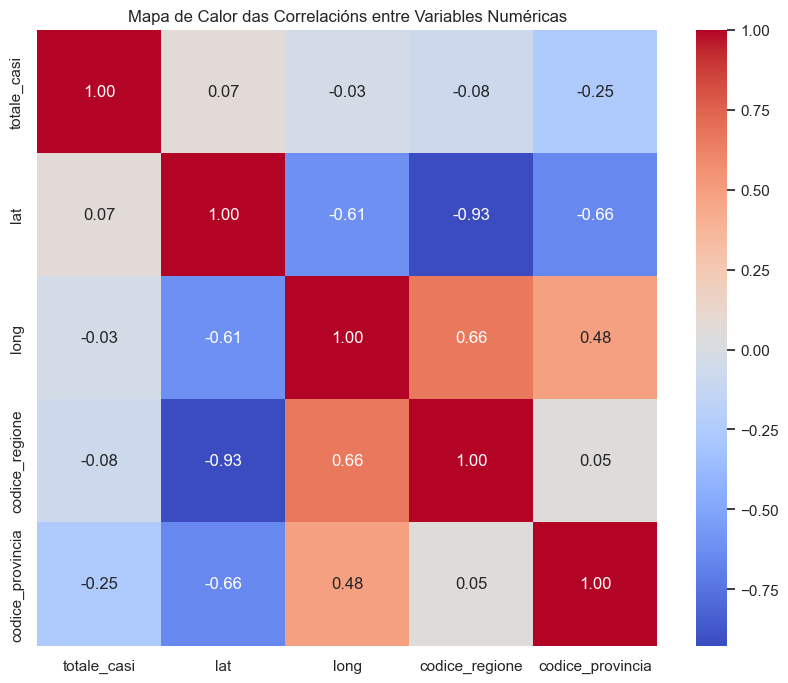

In [ ]:
# Gráfico 4: Heatmap (correlación entre variables numéricas)
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")
correlation_matrix = df[['totale_casi', 'lat', 'long', 'codice_regione', 'codice_provincia']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor das Correlacións entre Variables Numéricas')
plt.show()

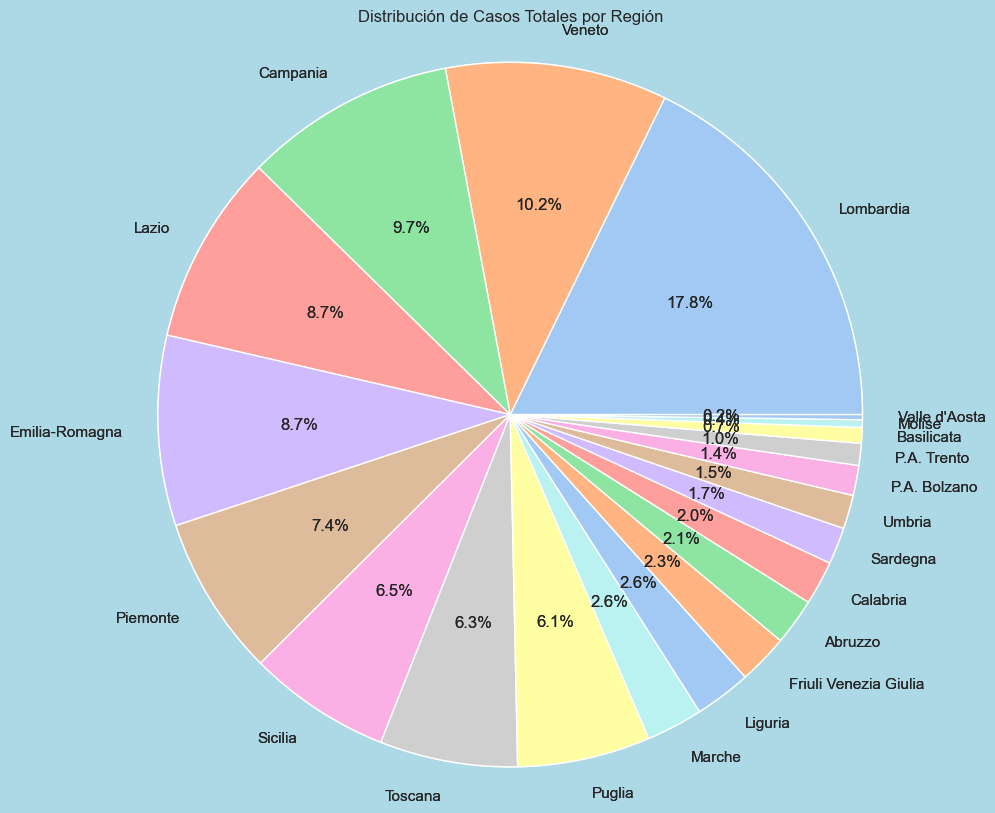

In [ ]:
# Gráfico de diagrama de sectores (pie chart)
# Agrupando por región y sumando los casos totales
df_grouped = df.groupby('denominazione_regione')['totale_casi'].sum().reset_index()
df_grouped = df_grouped.sort_values(by='totale_casi', ascending=False)
df_grouped['denominazione_regione'] = df_grouped['denominazione_regione'].astype(str)  # Asegurando que sea un string
df_grouped = df_grouped[df_grouped['totale_casi'] > 0]  # Filtrando regiones con casos totales > 0
df = df_grouped.copy()


# Gráfico de diagrama de sectores (pie chart)
plt.figure(figsize=(10, 10))  # Tamaño cuadrado
plt.pie(df['totale_casi'], 
        labels=df['denominazione_regione'],
        autopct='%1.1f%%')
#colores personalizados
colores = sns.color_palette("pastel", len(df['denominazione_regione']))
#fondo personalizado
plt.gcf().patch.set_facecolor('lightblue')
plt.pie(df['totale_casi'], labels=df['denominazione_regione'], autopct='%1.1f%%', colors=colores)
plt.title('Distribución de Casos Totales por Región')
plt.axis('equal')  # Para que el pie chart sea un círculo
plt.show()


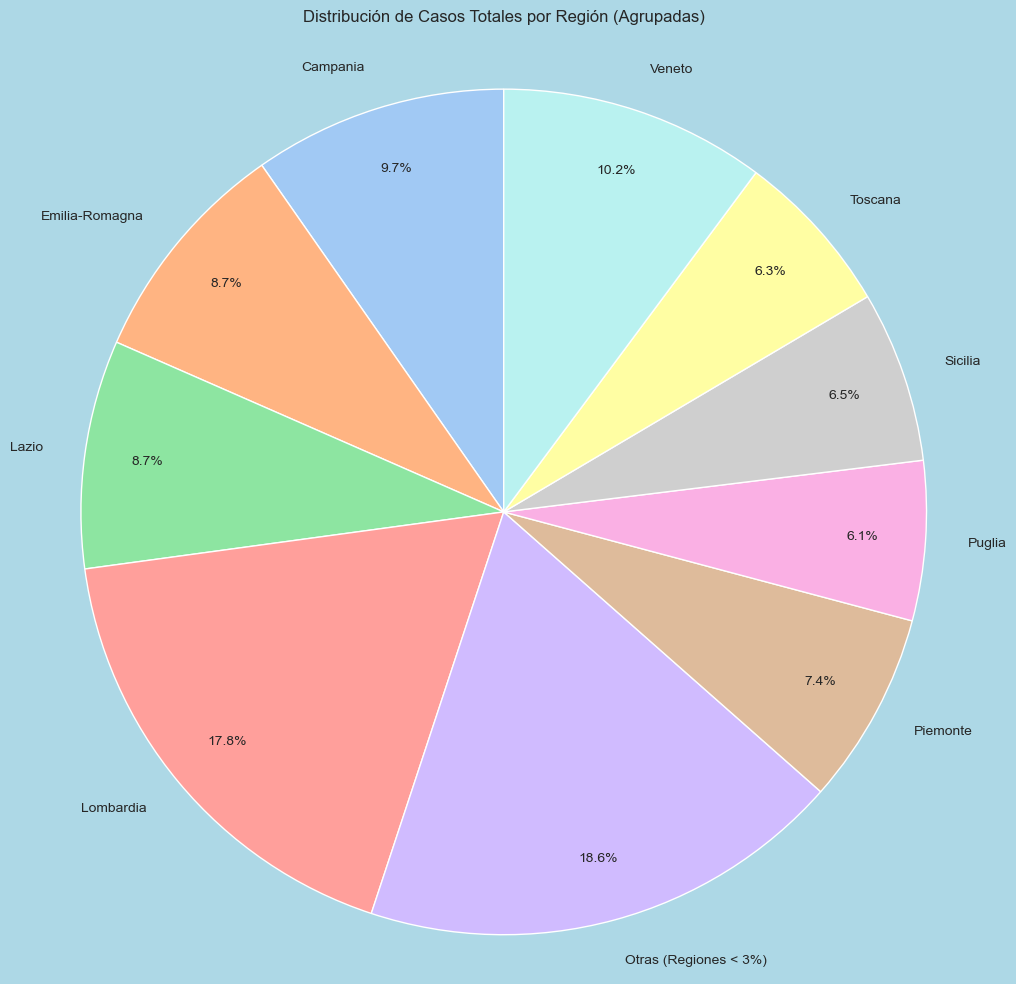

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar regiones con menos del 3% en "Otras"
df_grouped['category'] = df_grouped['denominazione_regione'].where(
    df_grouped['totale_casi'] / df_grouped['totale_casi'].sum() * 100 >= 3.0,
    "Otras (Regiones < 3%)"
)
df_agg = df_grouped.groupby('category')['totale_casi'].sum().reset_index()

# Crear el pie chart
plt.figure(figsize=(10, 10))
colores = sns.color_palette("pastel", len(df_agg))

# Ajustar parámetros de visualización
plt.pie(
    df_agg['totale_casi'],
    labels=df_agg['category'],
    autopct='%1.1f%%',
    colors=colores,
    textprops={'fontsize': 10},  # Tamaño de fuente
    pctdistance=0.85,            # Posición del porcentaje
    startangle=90                # Ángulo inicial
)
# Fondo personalizado
plt.gcf().patch.set_facecolor('lightblue')

plt.title('Distribución de Casos Totales por Región (Agrupadas)', pad=20)
plt.axis('equal')
plt.tight_layout()  # Evitar superposición
plt.show()